# Análisis Exploratorio y Selección de Variables

En este notebook se realiza el análisis exploratorio del dataset maestro construido previamente.

Los objetivos son:

- Comprender la distribución de las variables.
- Analizar la variable objetivo.
- Detectar correlaciones.
- Identificar posibles problemas de multicolinealidad.
- Seleccionar las variables más relevantes para el entrenamiento de modelos de Machine Learning.

## 1. Importación de librerías

Se cargan las librerías necesarias para el análisis estadístico y visualización de datos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset

Se carga el dataset final generado en la fase de preparación de datos.

In [2]:
dataset = pd.read_csv(
    "dataset_mundial_final.csv"
)

## 3. Inspección inicial

Se verifica la estructura general del dataset.

In [4]:
dataset.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,goal_diff,tournament_weight,fifa_rank_home,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
0,2000-03-19,Cayman Islands,Cuba,0.0,0.0,FIFA World Cup qualification,False,0.0,6,149.0,...,1.0,-1.0,5.0,8.0,7.0,1.0,-4.0,-8.0,-6.0,-2.0
1,2000-03-19,Dominica,Haiti,1.0,3.0,FIFA World Cup qualification,False,-2.0,6,152.0,...,0.0,2.0,7.0,5.0,12.0,-7.0,-4.0,-3.0,-12.0,9.0
2,2000-03-19,Bermuda,British Virgin Islands,9.0,0.0,FIFA World Cup qualification,False,9.0,6,157.0,...,2.0,-2.0,3.0,4.0,8.0,-4.0,-3.0,-4.0,-6.0,2.0
3,2000-03-25,Bahrain,Jordan,1.0,1.0,Friendly,False,0.0,1,139.0,...,1.0,0.0,8.0,6.0,5.0,1.0,-5.0,-5.0,-4.0,-1.0
4,2000-03-25,Zambia,Botswana,3.0,0.0,COSAFA Cup,False,3.0,3,38.0,...,5.0,1.0,4.0,4.0,8.0,-4.0,2.0,2.0,-3.0,5.0


In [3]:
dataset.shape

(16704, 30)

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 16704 entries, 0 to 16703
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      16704 non-null  str    
 1   home_team                 16704 non-null  str    
 2   away_team                 16704 non-null  str    
 3   home_score                16704 non-null  float64
 4   away_score                16704 non-null  float64
 5   tournament                16704 non-null  str    
 6   neutral                   16704 non-null  bool   
 7   goal_diff                 16704 non-null  float64
 8   tournament_weight         16704 non-null  int64  
 9   fifa_rank_home            16704 non-null  float64
 10  fifa_points_home          16704 non-null  float64
 11  fifa_rank_away            16704 non-null  float64
 12  fifa_points_away          16704 non-null  float64
 13  elo_home                  16704 non-null  float64
 14  elo_away         

In [6]:
dataset.describe()

,home_score,away_score,goal_diff,tournament_weight,fifa_rank_home,fifa_points_home,fifa_rank_away,fifa_points_away,elo_home,elo_away,...,home_last5_goals_against,home_last5_goal_balance,away_last5_points,away_last5_goals_for,away_last5_goals_against,away_last5_goal_balance,form_points_diff,form_goals_for_diff,form_goals_against_diff,form_goal_balance_diff
count,16704.000000,16704.000000,16704.000000,16704.000000,16704.00000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,...,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000,16704.000000
mean,1.552862,1.065074,0.487787,4.035740,78.75467,798.669767,82.061243,782.175307,1533.593511,1511.076269,...,5.254550,2.594289,5.432172,5.332854,7.804119,-2.471264,2.921157,2.515984,-2.549569,5.065553
std,1.515320,1.212852,2.100759,2.529189,52.93782,471.017738,52.899956,463.058723,284.500151,284.305987,...,3.303808,5.840542,3.334395,3.170005,4.300060,6.090922,4.523483,4.817658,5.041568,7.838928
min,0.000000,0.000000,-14.000000,1.000000,1.00000,0.000000,1.000000,0.000000,497.000000,497.000000,...,0.000000,-45.000000,0.000000,0.000000,0.000000,-42.000000,-14.000000,-22.000000,-38.000000,-38.000000
25%,0.000000,0.000000,-1.000000,1.000000,33.00000,405.000000,38.000000,399.000000,1342.750000,1330.000000,...,3.000000,-1.000000,3.000000,3.000000,5.000000,-6.000000,0.000000,-1.000000,-5.000000,0.000000
50%,1.000000,1.000000,0.000000,4.000000,73.00000,701.000000,77.000000,681.000000,1547.000000,1530.000000,...,5.000000,3.000000,5.000000,5.000000,7.000000,-2.000000,3.000000,2.000000,-2.000000,5.000000
75%,2.000000,2.000000,2.000000,6.000000,117.00000,1198.000000,120.000000,1174.992500,1734.000000,1712.000000,...,7.000000,6.000000,8.000000,7.000000,10.000000,1.000000,6.000000,5.000000,1.000000,10.000000
max,17.000000,14.000000,17.000000,10.000000,211.00000,2164.000000,211.000000,2164.000000,2167.000000,2167.000000,...,48.000000,36.000000,15.000000,27.000000,43.000000,25.000000,15.000000,33.000000,38.000000,59.000000


## 4. Verificación de valores faltantes

Se comprueba que el dataset no contiene valores nulos.

In [7]:
dataset.isna().sum()

date                        0
home_team                   0
away_team                   0
home_score                  0
away_score                  0
tournament                  0
neutral                     0
goal_diff                   0
tournament_weight           0
fifa_rank_home              0
fifa_points_home            0
fifa_rank_away              0
fifa_points_away            0
elo_home                    0
elo_away                    0
fifa_rank_diff              0
fifa_points_diff            0
elo_diff                    0
home_last5_points           0
home_last5_goals_for        0
home_last5_goals_against    0
home_last5_goal_balance     0
away_last5_points           0
away_last5_goals_for        0
away_last5_goals_against    0
away_last5_goal_balance     0
form_points_diff            0
form_goals_for_diff         0
form_goals_against_diff     0
form_goal_balance_diff      0
dtype: int64

## 5. Análisis de la variable objetivo

La variable objetivo del problema es la diferencia de goles.

Valores positivos indican victoria del equipo local.

Valores negativos indican victoria del equipo visitante.

El valor cero representa empate.

In [8]:
dataset["goal_diff"].describe()

count    16704.000000
mean         0.487787
std          2.100759
min        -14.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max         17.000000
Name: goal_diff, dtype: float64

In [9]:
dataset["goal_diff"].value_counts().sort_index()

goal_diff
-14.0       1
-13.0       1
-11.0       1
-10.0       3
-9.0        2
-8.0       12
-7.0       19
-6.0       58
-5.0       87
-4.0      235
-3.0      597
-2.0     1279
-1.0     2468
 0.0     3998
 1.0     3510
 2.0     2135
 3.0     1147
 4.0      578
 5.0      285
 6.0      139
 7.0       78
 8.0       32
 9.0       15
 10.0      14
 11.0       2
 12.0       1
 13.0       2
 14.0       3
 15.0       1
 17.0       1
Name: count, dtype: int64

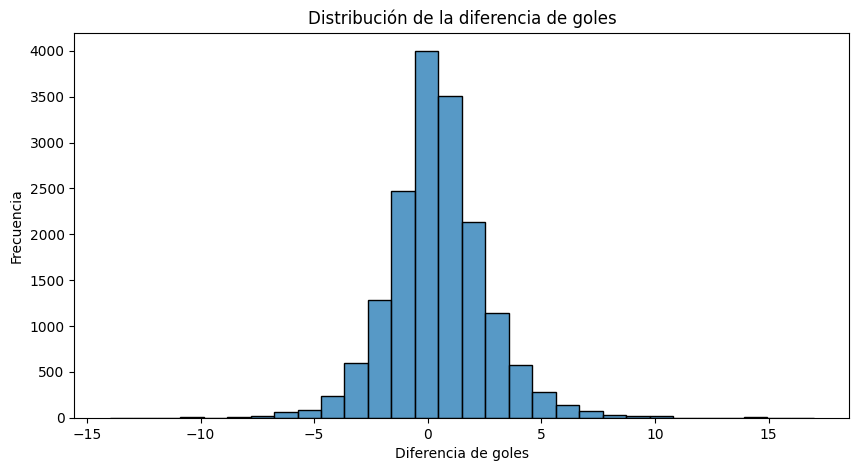

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    dataset["goal_diff"],
    bins=30
)

plt.title("Distribución de la diferencia de goles")
plt.xlabel("Diferencia de goles")
plt.ylabel("Frecuencia")

plt.savefig(
    "histograma_goal_diff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

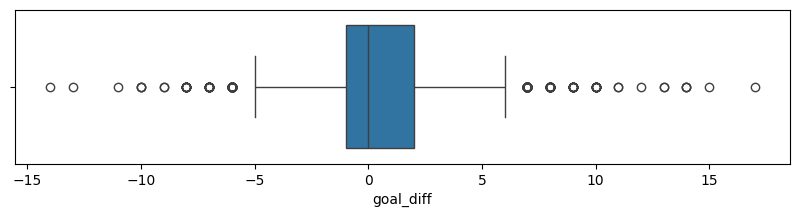

In [11]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=dataset["goal_diff"]
)

plt.show()